# Notebook with initial analysis and data handeling piplines

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import gzip
import json

## Load and explore the SPoRC dataset

#### Load the full SPoRC dataset

In [ ]:
# Load the SPoRC dataset (12G!)
#dataset = load_dataset("blitt/SPoRC")

episodeLevelData.jsonl.gz:   0%|          | 0.00/12.3G [00:00<?, ?B/s]

#### Load sample subset of the SPoRC dataset

In [2]:
# Path to your sample file
file_path = r"C:\Users\naja\SynologyDrive\01 Skole\03 AU\7. Semester\Natural Language Processing\Project\episodeLevelDataSample.jsonl"

# Read JSONL line by line
dataset_sample = pd.read_json(file_path, lines=True)

In [3]:
print(dataset_sample.head())

                                          transcript  \
0   I'm Simon Shapiro and this is Sing Out Speak ...   
1   I'm Simon Shapiro and this is Sing Out Speak ...   
2   I'm Simon Shapiro and this is Sing Out Speak ...   
3   I'm Simon Shapiro and this is Sing Out Speak ...   
4   I'm Simon Shapiro and this is Sing Out Speak ...   

                                    rssUrl                        epTitle  \
0  https://feeds.buzzsprout.com/783020.rss  Best of SingOut SpeakOut No.3   
1  https://feeds.buzzsprout.com/783020.rss                  It's All Gone   
2  https://feeds.buzzsprout.com/783020.rss             Today Is Yesterday   
3  https://feeds.buzzsprout.com/783020.rss                  Saturn Return   
4  https://feeds.buzzsprout.com/783020.rss             Quarterlife Crisis   

                                       epDescription  \
0  <p>Best of with snippets from 3 episodes and a...   
1  <p>Simon introduces &apos;It&apos;s all Gone&a...   
2  <p>Simon introduces track 4, 

In [4]:
print(f"Columns: \n{dataset_sample.columns}")

Columns: 
Index(['transcript', 'rssUrl', 'epTitle', 'epDescription', 'mp3url',
       'podTitle', 'lastUpdate', 'itunesAuthor', 'itunesOwnerName', 'explicit',
       'imageUrl', 'language', 'createdOn', 'host', 'podDescription',
       'category1', 'category2', 'category3', 'category4', 'category5',
       'category6', 'category7', 'category8', 'category9', 'category10',
       'oldestEpisodeDate', 'episodeDateLocalized', 'durationSeconds',
       'hostPredictedNames', 'numUniqueHosts', 'guestPredictedNames',
       'numUniqueGuests', 'neitherPredictedNames', 'numUniqueNeithers',
       'mainEpSpeakers', 'numMainSpeakers', 'hostSpeakerLabels',
       'guestSpeakerLabels', 'overlapPropTurnCount', 'avgTurnDuration',
       'overlapPropDuration', 'totalSpLabels'],
      dtype='object')


In [5]:
print(f"Number of episodes: {len(dataset_sample)}")

Number of episodes: 10000


#### One transcript

In [6]:
episode = dataset_sample.iloc[0]["transcript"] # the first episodes transcript
print(f"Transcript sample: {episode[:500]}...") # preview the first 500 chars

Transcript sample:  I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. So here are my five F's of being five. Fantasy. Kids are amazing at jumping into fantasy, not just make believe but b...


#### Semantic segmentation for the transcript

In [7]:
import nltk
nltk.download("punkt")
from nltk.tokenize import sent_tokenize

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\naja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
# Split transcript into sentences
sentences = sent_tokenize(episode)
print(f"Number of sentences: {len(sentences)}")
print(f"First 5 sentences: {sentences[:5]}")

Number of sentences: 8
First 5 sentences: [" I'm Simon Shapiro and this is Sing Out Speak Out.", "Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me.", "My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out.", "So here are my five F's of being five.", 'Fantasy.']


In [9]:
# Embed sentences
model = SentenceTransformer("all-MiniLM-L6-v2") # small, fast model
embeddings = model.encode(sentences)

In [10]:
# Compute similarity between consecutive sentences
sim_scores = []
for i in range(len(embeddings) - 1):
    sim = cosine_similarity([embeddings[i]], [embeddings[i + 1]])[0][0]
    sim_scores.append(sim)

In [11]:
# Identify breakpoints
# Low similarity indicates potential topic shift
threshold = 0.7 # adjust if needed
breakpoints = [i + 1 for i, score in enumerate(sim_scores) if score < threshold]

# Add start and end
segment_indices = [0] + breakpoints + [len(sentences)]

In [12]:
# Build segments
segments = [" ".join(sentences[segment_indices[i]:segment_indices[i + 1]]) for i in range(len(segment_indices) - 1)]

print(f"Number of sementic segments: {len(segments)}")
print(f"First 3 segments: {segments[:3]}")

Number of sementic segments: 8
First 3 segments: [" I'm Simon Shapiro and this is Sing Out Speak Out.", "Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me.", "My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out."]


#### Semantic segmentation function

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_segmentation(text, threshold=0.7):
    sentences = sent_tokenize(text)
    if len(sentences) < 2:
        return [text]  # single-segment fallback
    
    embeddings = model.encode(sentences)
    sim_scores = [cosine_similarity([embeddings[i]], [embeddings[i + 1]])[0][0]
                  for i in range(len(embeddings) - 1)]
    
    breakpoints = [i + 1 for i, score in enumerate(sim_scores) if score < threshold]
    segment_indices = [0] + breakpoints + [len(sentences)]
    segments = [" ".join(sentences[segment_indices[i]:segment_indices[i + 1]]) 
                for i in range(len(segment_indices) - 1)]
    
    return segments

#### Apply to all sample episodes

In [ ]:
all_segments = []

for i, row in dataset_sample.head(10).iterrows():  # use .head(x) for now, test with x episodes
    episode_text = row["transcript"]
    segments = semantic_segmentation(episode_text, threshold=0.7)
    for j, seg in enumerate(segments):
        all_segments.append({
            "episode_id": i,
            "segment_id": j,
            "text": seg
        })

segments_dataset_sample = pd.DataFrame(all_segments)
print(f"Total segments extracted: {len(segments_dataset_sample)}")
segments_dataset_sample.head()

Total segments extracted: 1937


,episode_id,segment_id,text
0,0,0,I'm Simon Shapiro and this is Sing Out Speak ...
1,0,1,"Here I give you the philosophies, ideas and so..."
2,0,2,My will to connect with you and share the best...
3,0,3,So here are my five F's of being five.
4,0,4,Fantasy.


#### Topic modeling across all episodes in the sample dataset

In [18]:
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizer for high-quality topic extraction
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")

# Create BERTopic model
# Use KMeans instead of HDBSCAN
kmeans = KMeans(n_clusters=10, random_state=42)
topic_model = BERTopic(hdbscan_model=kmeans, vectorizer_model=vectorizer_model)

# Fit-transform on your segment texts
topics, probs = topic_model.fit_transform(segments_dataset_sample["text"])

# Store topics
segments_dataset_sample["topic"] = topics

# Inspect results
segments_dataset_sample.head(10)

,episode_id,segment_id,text,topic
0,0,0,I'm Simon Shapiro and this is Sing Out Speak ...,3
1,0,1,"Here I give you the philosophies, ideas and so...",3
2,0,2,My will to connect with you and share the best...,3
3,0,3,So here are my five F's of being five.,2
4,0,4,Fantasy.,0
5,0,5,"Kids are amazing at jumping into fantasy, not ...",1
6,0,6,We're in the car waiting for someone to come a...,0
7,0,7,I suggest let's pretend we're space man.,0
8,1,0,I'm Simon Shapiro and this is Sing Out Speak ...,3
9,1,1,"Here I give you the philosophies, ideas and so...",3


In [ ]:
# Extract topic info
topic_info = topic_model.get_topic_info()
print(topic_info.head())

# We can rename topics like:
# topic_model.set_topic_labels({0: "Intro / Context", 1: "Personal Reflection", 2: "Childhood / Imagination", ...})

   Topic  Count                                     Name  \
0      0    341                      0_like_know_im_dont   
1      1    284                  1_know_theyre_like_just   
2      2    281                 2_school_know_youre_like   
3      3    213  3_music_music music_california_students   
4      4    192                4_like_just_players_going   

                                      Representation  \
0  [like, know, im, dont, time, going, youre, doi...   
1  [know, theyre, like, just, home, im, going, th...   
2  [school, know, youre, like, children, im, dont...   
3  [music, music music, california, students, edu...   
4  [like, just, players, going, hockey, think, te...   

                                 Representative_Docs  
0  [So, you know, you know, like, the world is th...  
1  [They get to just be., And to know that for th...  
2  [And what I found interesting, it sounds like ...  
3  [[Music] [Music] [Music] [Music] [Music] [Musi...  
4  [We're talking about the

#### Map transitions (narrative flow)

In [20]:
import networkx as nx

# Build topic transition pairs per episode
edges = []
for eid, group in segments_dataset_sample.groupby("episode_id"):
    topics_seq = list(group["topic"])
    for a, b in zip(topics_seq[:-1], topics_seq[1:]):
        edges.append((a, b))

# Create weighted graph of transitions
G = nx.DiGraph()
for edge in edges:
    if G.has_edge(*edge):
        G[edge[0]][edge[1]]["weight"] += 1
    else:
        G.add_edge(edge[0], edge[1], weight=1)

print(f"Graph has {len(G.nodes())} topics and {len(G.edges())} transitions.")

Graph has 10 topics and 99 transitions.


#### Visualization of the conversation journey

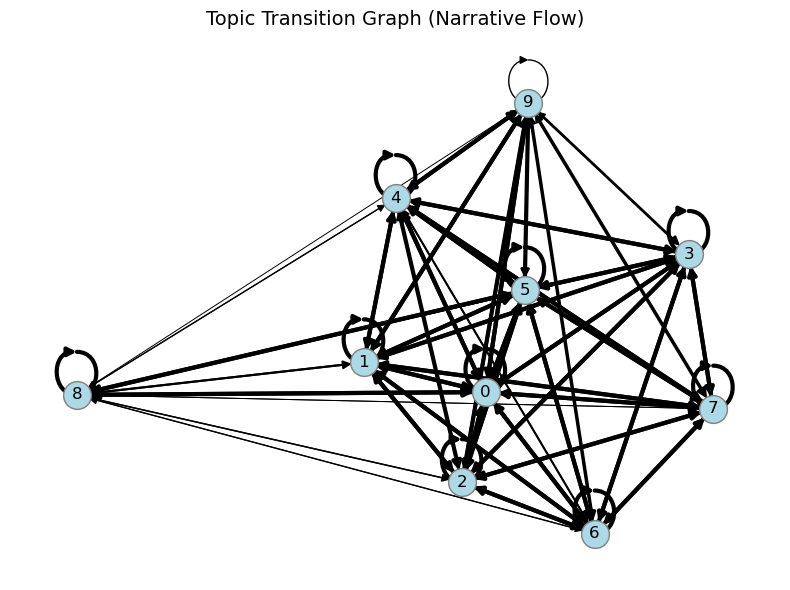

In [62]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

# Normalize edge weights for visibility
weights = [max(0.7, min(G[u][v]["weight"] / 2, 3)) for u, v in G.edges()]
#weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=400, node_color="lightblue", edgecolors="gray")
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, width=weights, arrows=True, arrowstyle="-|>", arrowsize=12)

plt.title("Topic Transition Graph (Narrative Flow)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

##### Sankey diagram (looks weird)

In [75]:
import plotly.graph_objects as go

# Reindex nodes so they are consecutive integers starting at 0
node_list = list(G.nodes())  # e.g., [0, 1, 2, 4, 8]
node_indices = {node: i for i, node in enumerate(node_list)}

sources = [node_indices[u] for u, v in G.edges()]
targets = [node_indices[v] for u, v in G.edges()]
values = [G[u][v]["weight"] for u, v in G.edges()]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=[str(t) for t in node_list], pad=15, thickness=20),
    link=dict(source=sources, target=targets, value=values)
)])

fig.update_layout(title_text="Topic Flow Across Podcast Segments", font_size=10)
fig.show()

In [74]:
import networkx as nx
import plotly.graph_objects as go

# Compute a 2D layout
pos = nx.spring_layout(G, seed=42)  # positions as {node: [x, y]}

# Extract node list
node_list = list(G.nodes())
node_indices = {n: i for i, n in enumerate(node_list)}

# Normalize x and y to 0–1
xs = [pos[n][0] for n in node_list]
ys = [pos[n][1] for n in node_list]

x_min, x_max = min(xs), max(xs)
y_min, y_max = min(ys), max(ys)

x = [(xi - x_min) / (x_max - x_min) for xi in xs]
y = [(yi - y_min) / (y_max - y_min) for yi in ys]

# Prepare links
sources = [node_indices[u] for u, v in G.edges()]
targets = [node_indices[v] for u, v in G.edges()]
values = [G[u][v]["weight"] for u, v in G.edges()]

# Create Sankey
fig = go.Figure(go.Sankey(
    node=dict(
        label=[str(n) for n in node_list],
        pad=15,
        thickness=20,
        x=x,
        y=y
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(title_text="Topic Flow Across Podcast Segments", font_size=10)
fig.show()


## Pipeline

### Semantic Segmentation

### Topic Labeling

### Graph Modeling

### Visualization